In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [11]:
observations = 1000
xs = np.random.uniform(low=-10, high=10, size=(observations, 1))
zs = np.random.uniform(low=-10,high=10, size=(observations, 1))
inputs = np.column_stack((xs, zs))
print(inputs.shape)

(1000, 2)


In [12]:
noise = np.random.uniform(low=-1,high=1, size=(observations, 1))
targets = 2*xs - 3*zs + 5 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(1000, 1)


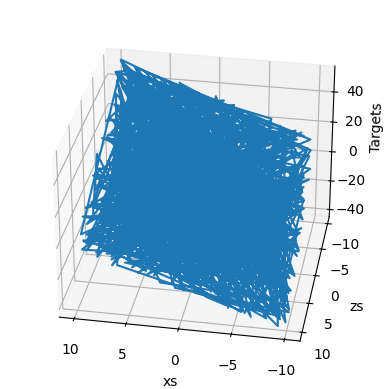

In [13]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, zs, targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [14]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2, 1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights,biases)

[[ 0.09833385]
 [-0.00874584]] [-0.01147969]


In [15]:
targets = targets.reshape(observations,1)
eta = 0.02
for i in range(100):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2) / 2 / observations
  print(loss)

  deltas_scaled = deltas / observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

225.86206672178224
34.02400231276709
13.91686148985595
11.444146759875002
10.799146802151888
10.357692508671402
9.952068888987666
9.564396920083361
9.192264585954806
8.834880431618505
8.491642407058578
8.161988737659133
7.8453816012441555
7.541304641453255
7.249261956583985
6.9687772729832185
6.699393166419055
6.4406703158927305
6.192186787156382
5.953537344605521
5.7243327904064065
5.504199329778614
5.2927779613974675
5.0897238919221515
4.8947059736947205
4.707406164692938
4.527519009856268
4.354751142939087
4.188820808078803
4.0294574002985595
3.8764010241951934
3.729402070092766
3.588220806970386
3.4526269915004986
3.322399492560043
3.1973259306021027
3.077202331299938
2.96183279289853
2.85102916673118
2.7446107503800903
2.642403992980567
2.5442422121882156
2.4499653223475555
2.3594195734187595
2.2724573002367205
2.188936681693549
2.108721509451769
2.031680965811009
1.9576894103659375
1.8866261751075017
1.8183753676333323
1.752825682146374
1.6898702179335119
1.6294063050281535
1.571

In [16]:
print(weights, biases)

[[ 1.99988656]
 [-2.99777058]] [4.3212198]


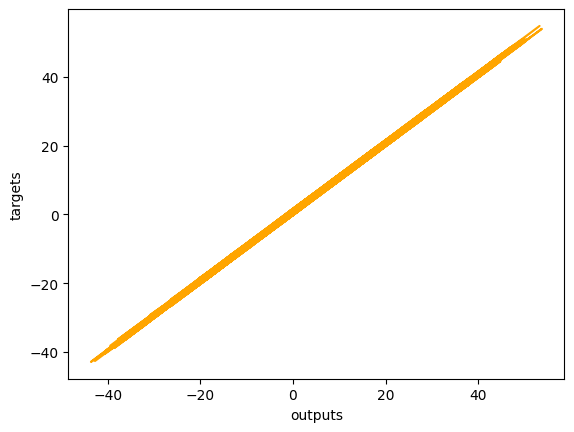

In [17]:
plt.plot(outputs,targets,color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()